In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.ensemble import HistGradientBoostingClassifier
from imblearn.over_sampling import ADASYN
import warnings
warnings.filterwarnings('ignore')

# Install CatBoost if not already installed
try:
    from catboost import CatBoostClassifier
except ImportError:
    print("CatBoost not found. Installing...")
    !pip install catboost -qq
    from catboost import CatBoostClassifier

# Import LightGBM
import lightgbm as lgb

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# ==============================================
# 1. DATA COLLECTION & UNDERSTANDING
# ==============================================
print("="*60)
print("1. DATA COLLECTION & UNDERSTANDING")
print("="*60)

df = pd.read_csv('tiete_wqi_1994-2019.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nDataset info:")
df.info()
print(f"\nStatistical summary:\n{df.describe()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

CatBoost not found. Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.1 MB/s eta 0:00:00
1. DATA COLLECTION & UNDERSTANDING
Dataset shape: (7101, 14)

First 5 rows:
   ugrhi macro_land_use measurement_points   ph   do  bod       tc     tn  \
0      5     industrial          CPIV02200  6.6  2.0    5   110000   4.27   
1      5     industrial          CPIV02200  6.9  0.8   36   900000   7.24   
2      5     industrial          CPIV02200  7.1  2.0   14   110000   6.35   
3      5     industrial          CPIV02200  7.4  0.6   16   210000  13.62   
4      5     industrial          CPIV02200  7.0  0.8   24  1700000  24.82   

      tp   ts  turb  temp  wqi classification  
0  0.419  277    96  23.0   29            bad  
1  1.160  669   210  23.0   14       very_bad  
2  0.455  261    72  22.0   27            bad  
3  1.250  272    46  16.0   20            bad  
4  3.200  559    60  22.0   16       very_bad  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeInd


2. EDA & HEATMAP KORELASI FITUR vs TARGET

Distribusi kelas target:
classification
good        2243
bad         1694
very_bad    1511
medium       834
excelent     819
Name: count, dtype: int64


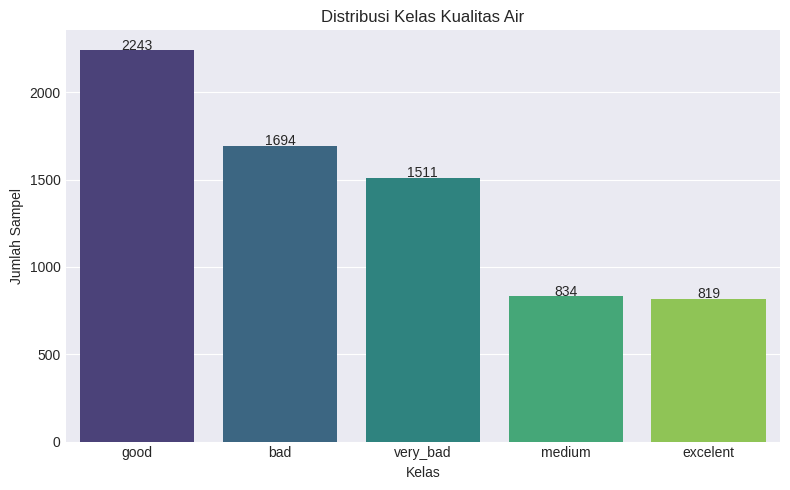


Fitur numerik: ['ph', 'do', 'bod', 'tc', 'tn', 'tp', 'ts', 'turb', 'temp']
Fitur kategorikal: ['macro_land_use']


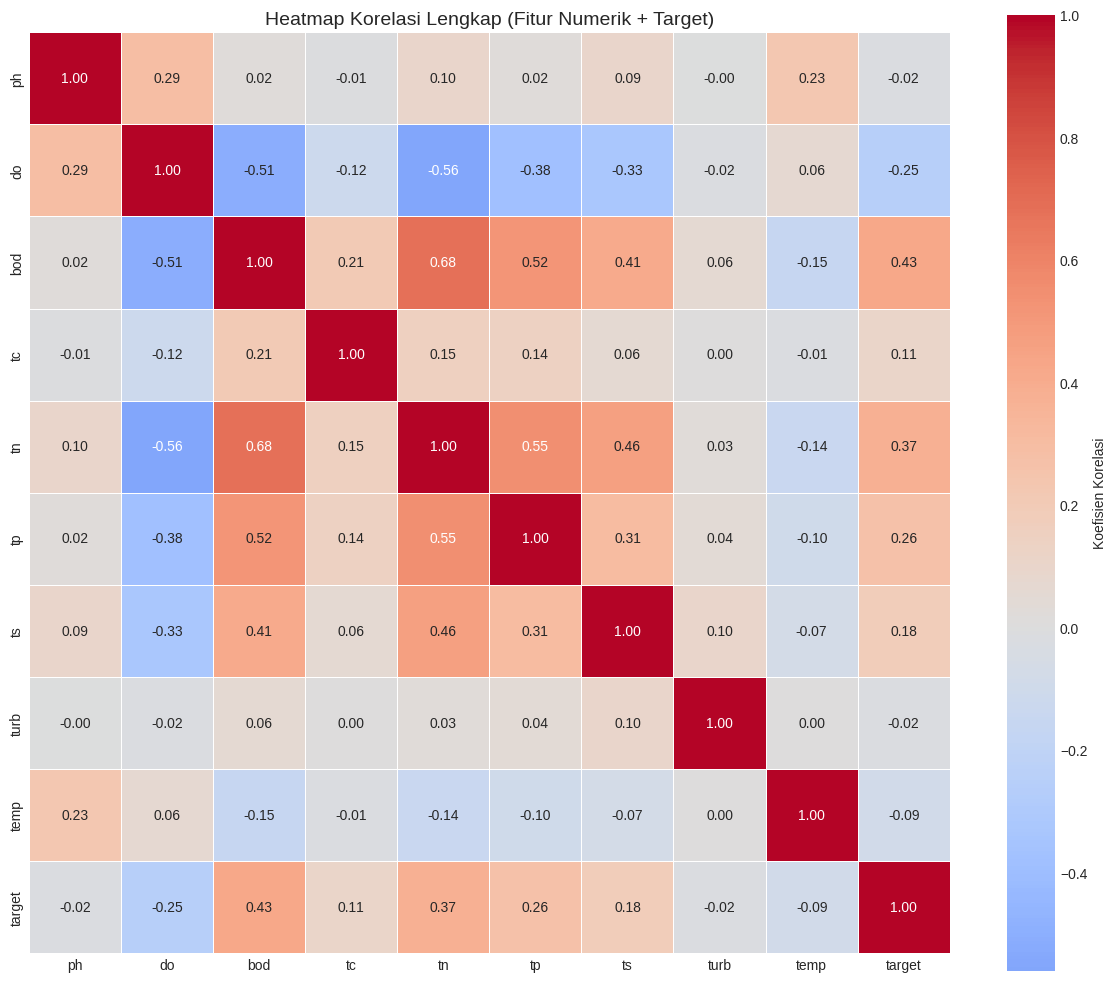


Korelasi setiap fitur numerik dengan target:
bod     0.425147
tn      0.372662
tp      0.263785
ts      0.179407
tc      0.105749
turb   -0.016018
ph     -0.023279
temp   -0.086712
do     -0.252301
Name: target, dtype: float64


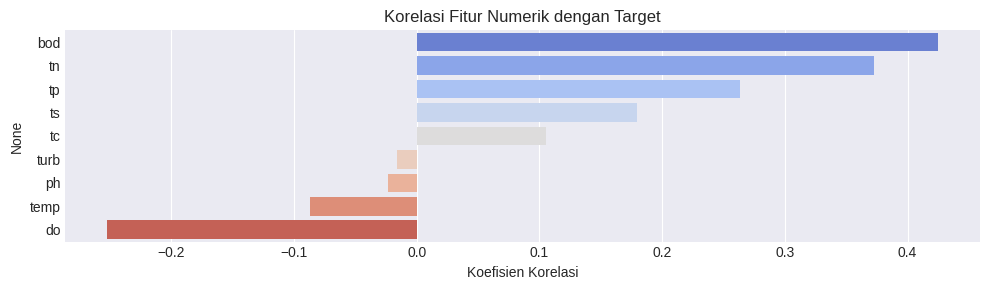

In [ ]:

# ==============================================
# 2. EDA & HEATMAP KORELASI FITUR vs TARGET
# ==============================================
print("\n" + "="*60)
print("2. EDA & HEATMAP KORELASI FITUR vs TARGET")
print("="*60)

target_counts = df['classification'].value_counts()
print("\nDistribusi kelas target:")
print(target_counts)

plt.figure(figsize=(8,5))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Distribusi Kelas Kualitas Air')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')
for i, v in enumerate(target_counts.values):
    plt.text(i, v+2, str(v), ha='center')
plt.tight_layout()
plt.show()

numeric_cols = ['ph', 'do', 'bod', 'tc', 'tn', 'tp', 'ts', 'turb', 'temp']
categorical_cols = ['macro_land_use']
available_numeric = [col for col in numeric_cols if col in df.columns]
print(f"\nFitur numerik: {available_numeric}")
print(f"Fitur kategorikal: {categorical_cols}")

le_temp = LabelEncoder()
target_encoded = le_temp.fit_transform(df['classification'])
df_corr = df[available_numeric].copy()
df_corr['target'] = target_encoded
corr_full_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_full_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Koefisien Korelasi'})
plt.title('Heatmap Korelasi Lengkap (Fitur Numerik + Target)', fontsize=14)
plt.tight_layout()
plt.show()

corr_with_target = corr_full_matrix['target'].drop('target').sort_values(ascending=False)
print("\nKorelasi setiap fitur numerik dengan target:")
print(corr_with_target)

plt.figure(figsize=(10, 3))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Korelasi Fitur Numerik dengan Target')
plt.xlabel('Koefisien Korelasi')
plt.tight_layout()
plt.show()


In [ ]:

# ==============================================
# 3. PREPROCESSING: Persiapan Fitur dan Target
# ==============================================
print("\n" + "="*60)
print("3. PREPROCESSING: Persiapan Fitur dan Target")
print("="*60)

X = df[available_numeric + categorical_cols].copy()
y = df['classification'].copy()

le = LabelEncoder()
y_encoded = le.fit_transform(y)
target_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Pemetaan kelas: {target_mapping}")


3. PREPROCESSING: Persiapan Fitur dan Target
Pemetaan kelas: {'bad': np.int64(0), 'excelent': np.int64(1), 'good': np.int64(2), 'medium': np.int64(3), 'very_bad': np.int64(4)}


In [ ]:
# ==============================================
# 4. DATA SPLITTING (stratified)
# ==============================================
print("\n" + "="*60)
print("4. DATA SPLITTING (stratified)")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")



4. DATA SPLITTING (stratified)
Training set: (4970, 10), Test set: (2131, 10)



5. CAPPING OUTLIER + SCALING + ONE-HOT ENCODING
Jumlah fitur numerik: 9
Jumlah fitur kategorikal: 1

Informasi batas capping (berdasarkan data train):
  ph     | Q1=    6.90 | Q3=    7.40 | IQR=    0.50 | lower=      6.15 | upper=      8.15
  do     | Q1=    1.07 | Q3=    6.60 | IQR=    5.53 | lower=     -7.22 | upper=     14.89
  bod    | Q1=    3.00 | Q3=   24.00 | IQR=   21.00 | lower=    -28.50 | upper=     55.50
  tc     | Q1=  201.00 | Q3=533333.00 | IQR=533132.00 | lower=-799497.00 | upper=1333031.00
  tn     | Q1=    1.64 | Q3=   13.54 | IQR=   11.90 | lower=    -16.21 | upper=     31.38
  tp     | Q1=    0.06 | Q3=    1.03 | IQR=    0.97 | lower=     -1.39 | upper=      2.48
  ts     | Q1=  118.00 | Q3=  318.00 | IQR=  200.00 | lower=   -182.00 | upper=    618.00
  turb   | Q1=    9.00 | Q3=   40.00 | IQR=   31.00 | lower=    -37.50 | upper=     86.50
  temp   | Q1=   20.50 | Q3=   25.30 | IQR=    4.80 | lower=     13.30 | upper=     32.50


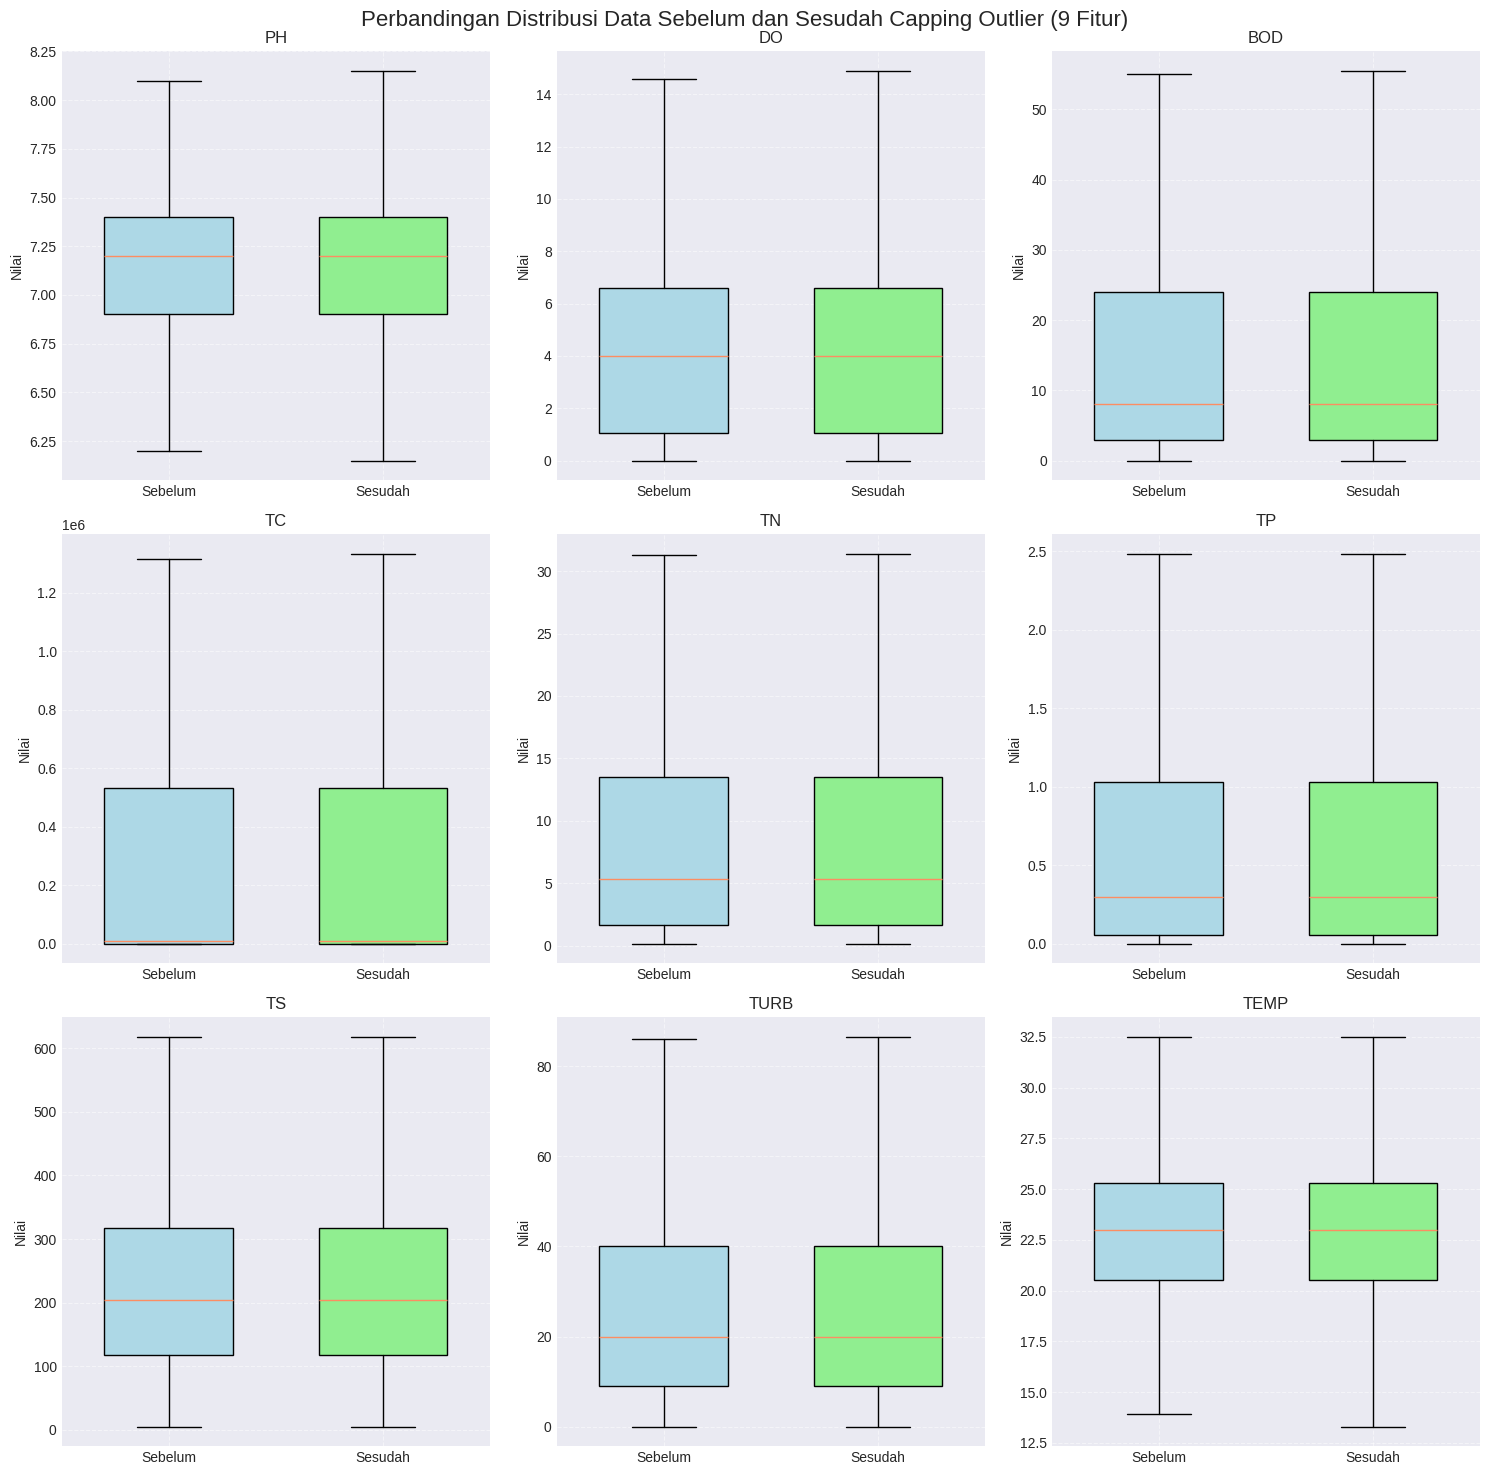


Scaling selesai. Parameter scaling (mean, std) disimpan dari data train.
One-hot encoding selesai. Kategori asli: ['agriculture' 'industrial' 'industrialization']
  -> Menjadi 2 kolom (drop='first')

HASIL PREPROCESSING:
  Dimensi data train: (4970, 11)
  Dimensi data test : (2131, 11)
  - Fitur numerik (scaled)   : 9 kolom
  - Fitur kategorikal (encoded): 2 kolom
  Total fitur                : 11
  Tidak ada data yang dihapus (capping hanya mengganti nilai)


In [ ]:
# ==============================================
# 5. PREPROCESSING: CAPPING OUTLIER + SCALING + ENCODING
# ==============================================
print("\n" + "="*60)
print("5. CAPPING OUTLIER + SCALING + ONE-HOT ENCODING")
print("="*60)

# Pisahkan fitur numerik dan kategorikal
X_train_num = X_train[available_numeric]
X_test_num = X_test[available_numeric]
X_train_cat = X_train[categorical_cols]
X_test_cat = X_test[categorical_cols]

print(f"Jumlah fitur numerik: {len(available_numeric)}")
print(f"Jumlah fitur kategorikal: {len(categorical_cols)}")

# ------------------------------------------------------------------
# Fungsi capping outlier
# ------------------------------------------------------------------
def cap_outliers(X_train, X_test, columns):
    X_train_capped = X_train.copy()
    X_test_capped = X_test.copy()
    cap_info = []
    for col in columns:
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        X_train_capped[col] = X_train[col].clip(lower, upper)
        X_test_capped[col] = X_test[col].clip(lower, upper)
        cap_info.append((col, lower, upper, Q1, Q3, IQR))
    return X_train_capped, X_test_capped, cap_info

X_train_capped, X_test_capped, cap_info = cap_outliers(X_train_num, X_test_num, available_numeric)

# Tampilkan informasi batas capping
print("\nInformasi batas capping (berdasarkan data train):")
for col, lower, upper, Q1, Q3, IQR in cap_info:
    print(f"  {col:6} | Q1={Q1:8.2f} | Q3={Q3:8.2f} | IQR={IQR:8.2f} | lower={lower:10.2f} | upper={upper:10.2f}")

# ------------------------------------------------------------------
# Visualisasi boxplot UNTUK SEMUA FITUR NUMERIK (sebelum dan sesudah capping)
# ------------------------------------------------------------------
n_features = len(available_numeric)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()  # ratakan untuk iterasi mudah

for idx, feat in enumerate(available_numeric):
    ax = axes[idx]
    # Data sebelum capping
    bp1 = ax.boxplot(X_train_num[feat], positions=[1], widths=0.6, patch_artist=True,
                     boxprops=dict(facecolor='lightblue'), showfliers=False)
    # Data sesudah capping
    bp2 = ax.boxplot(X_train_capped[feat], positions=[2], widths=0.6, patch_artist=True,
                     boxprops=dict(facecolor='lightgreen'), showfliers=False)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Sebelum', 'Sesudah'])
    ax.set_title(f'{feat.upper()}')
    ax.set_ylabel('Nilai')
    ax.grid(True, linestyle='--', alpha=0.5)

# Sembunyikan sumbu yang tidak terpakai (jika jumlah fitur tidak genap)
for idx in range(len(available_numeric), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Perbandingan Distribusi Data Sebelum dan Sesudah Capping Outlier (9 Fitur)', fontsize=16)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Scaling
# ------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_capped)
X_test_scaled = scaler.transform(X_test_capped)

print("\nScaling selesai. Parameter scaling (mean, std) disimpan dari data train.")

# ------------------------------------------------------------------
# One-hot encoding
# ------------------------------------------------------------------
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_train_cat_encoded = ohe.fit_transform(X_train_cat)
X_test_cat_encoded = ohe.transform(X_test_cat)

print(f"One-hot encoding selesai. Kategori asli: {ohe.categories_[0]}")
print(f"  -> Menjadi {X_train_cat_encoded.shape[1]} kolom (drop='first')")

# ------------------------------------------------------------------
# Gabungkan fitur
# ------------------------------------------------------------------
X_train_preprocessed = np.hstack([X_train_scaled, X_train_cat_encoded])
X_test_preprocessed = np.hstack([X_test_scaled, X_test_cat_encoded])

print("\n" + "="*40)
print("HASIL PREPROCESSING:")
print(f"  Dimensi data train: {X_train_preprocessed.shape}")
print(f"  Dimensi data test : {X_test_preprocessed.shape}")
print(f"  - Fitur numerik (scaled)   : {X_train_scaled.shape[1]} kolom")
print(f"  - Fitur kategorikal (encoded): {X_train_cat_encoded.shape[1]} kolom")
print(f"  Total fitur                : {X_train_preprocessed.shape[1]}")
print(f"  Tidak ada data yang dihapus (capping hanya mengganti nilai)")
print("="*40)

In [ ]:


# ==============================================
# 6. ADASYN (Adaptive Synthetic Sampling)
# ==============================================
print("\n" + "="*60)
print("6. ADASYN (Adaptive Synthetic Sampling)")
print("="*60)

unique_train, counts_train = np.unique(y_train, return_counts=True)
print("Distribusi kelas SEBELUM ADASYN:")
for label, count in zip(unique_train, counts_train):
    print(f"{le.inverse_transform([label])[0]}: {count}")

adasyn = ADASYN(random_state=42, n_neighbors=5)
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train_preprocessed, y_train)

unique_resampled, counts_resampled = np.unique(y_train_resampled, return_counts=True)
print("\nDistribusi kelas SETELAH ADASYN:")
for label, count in zip(unique_resampled, counts_resampled):
    print(f"{le.inverse_transform([label])[0]}: {count}")
print(f"Jumlah data training setelah ADASYN: {X_train_resampled.shape[0]} (bertambah dari {X_train_preprocessed.shape[0]})")


6. ADASYN (Adaptive Synthetic Sampling)
Distribusi kelas SEBELUM ADASYN:
bad: 1186
excelent: 573
good: 1570
medium: 584
very_bad: 1057

Distribusi kelas SETELAH ADASYN:
bad: 1576
excelent: 1492
good: 1570
medium: 1586
very_bad: 1600
Jumlah data training setelah ADASYN: 7824 (bertambah dari 4970)


In [ ]:


# ==============================================
# 7. HYPERPARAMETER TUNING (GridSearchCV)
# ==============================================
print("\n" + "="*60)
print("7. HYPERPARAMETER TUNING (GridSearchCV)")
print("="*60)

# Model dan parameter grid (hanya nilai terpenting, jumlah kombinasi kecil)
models = {
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbosity=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42)
}

param_grids = {
    'LightGBM': {
        'n_estimators': [100, 200],
        'max_depth': [5, 10],
        'learning_rate': [0.05, 0.1],
        'num_leaves': [31, 50]
    },
    'CatBoost': {
        'iterations': [100, 200],
        'depth': [4, 6],
        'learning_rate': [0.05, 0.1],
        'l2_leaf_reg': [1, 3]
    },
    'HistGradientBoosting': {
        'max_iter': [100, 200],
        'max_depth': [5, 10],
        'learning_rate': [0.05, 0.1],
        'min_samples_leaf': [20, 50]
    }
}

best_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\nTuning {name} dengan GridSearchCV...")
    grid = GridSearchCV(
        model, param_grids[name], cv=cv,
        scoring='accuracy', n_jobs=-1, verbose=1
    )
    grid.fit(X_train_resampled, y_train_resampled)
    best_models[name] = grid.best_estimator_
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV accuracy: {grid.best_score_:.4f}")


7. HYPERPARAMETER TUNING (GridSearchCV)

Tuning LightGBM dengan GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 31}
Best CV accuracy: 0.9594

Tuning CatBoost dengan GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'depth': 6, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Best CV accuracy: 0.9499

Tuning HistGradientBoosting dengan GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'learning_rate': 0.1, 'max_depth': 10, 'max_iter': 200, 'min_samples_leaf': 20}
Best CV accuracy: 0.9595



8. EVALUASI MODEL PADA DATA UJI

LightGBM Performance:
Accuracy: 0.9282
F1-Macro: 0.9179
F1-Weighted: 0.9280

Classification Report:
              precision    recall  f1-score   support

         bad       0.94      0.88      0.91       508
    excelent       0.97      0.91      0.94       246
        good       0.93      0.97      0.95       673
      medium       0.81      0.83      0.82       250
    very_bad       0.95      0.98      0.96       454

    accuracy                           0.93      2131
   macro avg       0.92      0.92      0.92      2131
weighted avg       0.93      0.93      0.93      2131



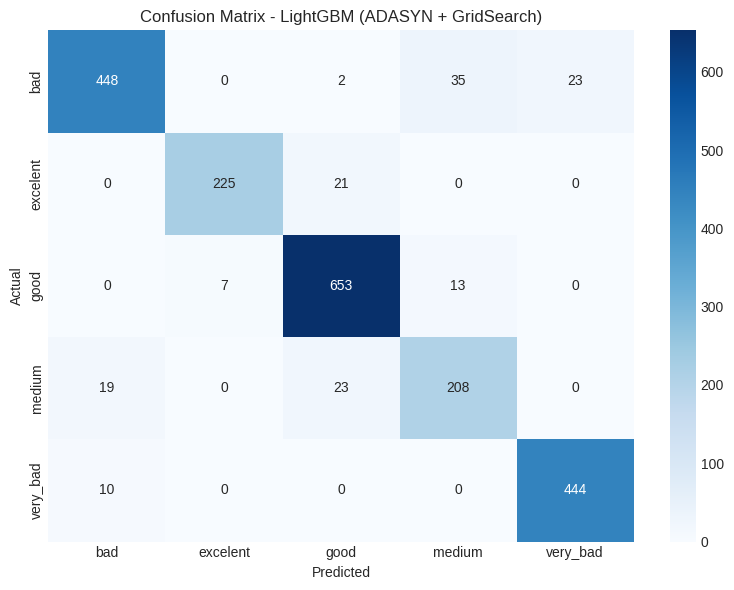


CatBoost Performance:
Accuracy: 0.9338
F1-Macro: 0.9256
F1-Weighted: 0.9342

Classification Report:
              precision    recall  f1-score   support

         bad       0.95      0.88      0.91       508
    excelent       0.93      0.97      0.95       246
        good       0.97      0.95      0.96       673
      medium       0.80      0.89      0.84       250
    very_bad       0.95      0.98      0.97       454

    accuracy                           0.93      2131
   macro avg       0.92      0.93      0.93      2131
weighted avg       0.94      0.93      0.93      2131



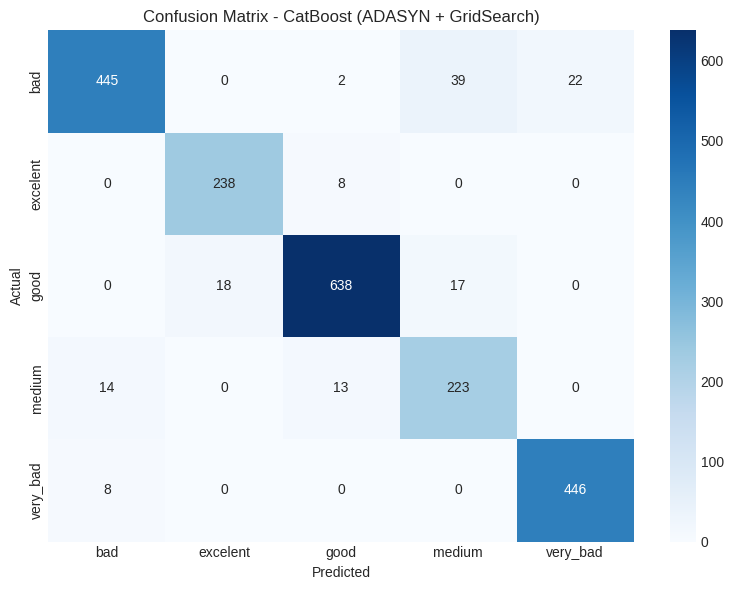


HistGradientBoosting Performance:
Accuracy: 0.9310
F1-Macro: 0.9215
F1-Weighted: 0.9310

Classification Report:
              precision    recall  f1-score   support

         bad       0.95      0.88      0.91       508
    excelent       0.96      0.93      0.94       246
        good       0.94      0.96      0.95       673
      medium       0.81      0.85      0.83       250
    very_bad       0.95      0.98      0.97       454

    accuracy                           0.93      2131
   macro avg       0.92      0.92      0.92      2131
weighted avg       0.93      0.93      0.93      2131



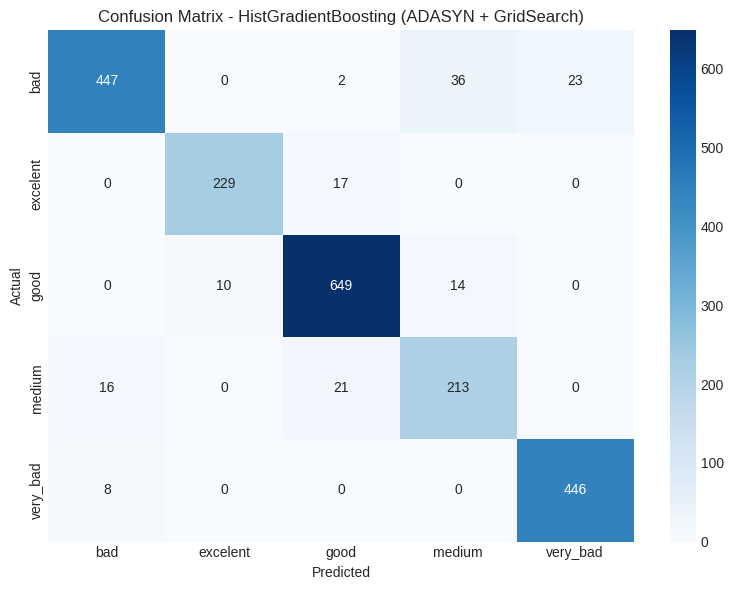

In [ ]:


# ==============================================
# 8. EVALUASI PADA DATA UJI
# ==============================================
print("\n" + "="*60)
print("8. EVALUASI MODEL PADA DATA UJI")
print("="*60)

results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test_preprocessed)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')

    results[name] = {
        'Accuracy': acc,
        'F1-Macro': f1_macro,
        'F1-Weighted': f1_weighted,
        'Precision (weighted)': prec,
        'Recall (weighted)': rec
    }

    print(f"\n{name} Performance:")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Macro: {f1_macro:.4f}")
    print(f"F1-Weighted: {f1_weighted:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name} (ADASYN + GridSearch)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


9. PERBANDINGAN MODEL

Tabel Perbandingan Metrik:
                      Accuracy  F1-Macro  F1-Weighted  Precision (weighted)  \
LightGBM                0.9282    0.9179       0.9280                0.9288   
CatBoost                0.9338    0.9256       0.9342                0.9361   
HistGradientBoosting    0.9310    0.9215       0.9310                0.9319   

                      Recall (weighted)  
LightGBM                         0.9282  
CatBoost                         0.9338  
HistGradientBoosting             0.9310  


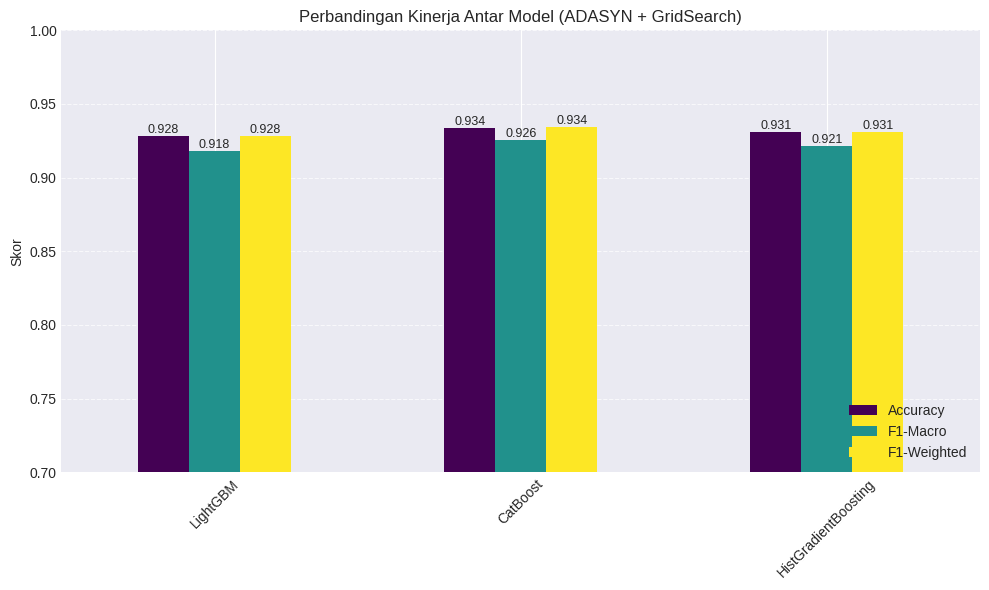


MODEL TERBAIK BERDASARKAN AKURASI: CatBoost
Akurasi: 0.9338, F1-Macro: 0.9256


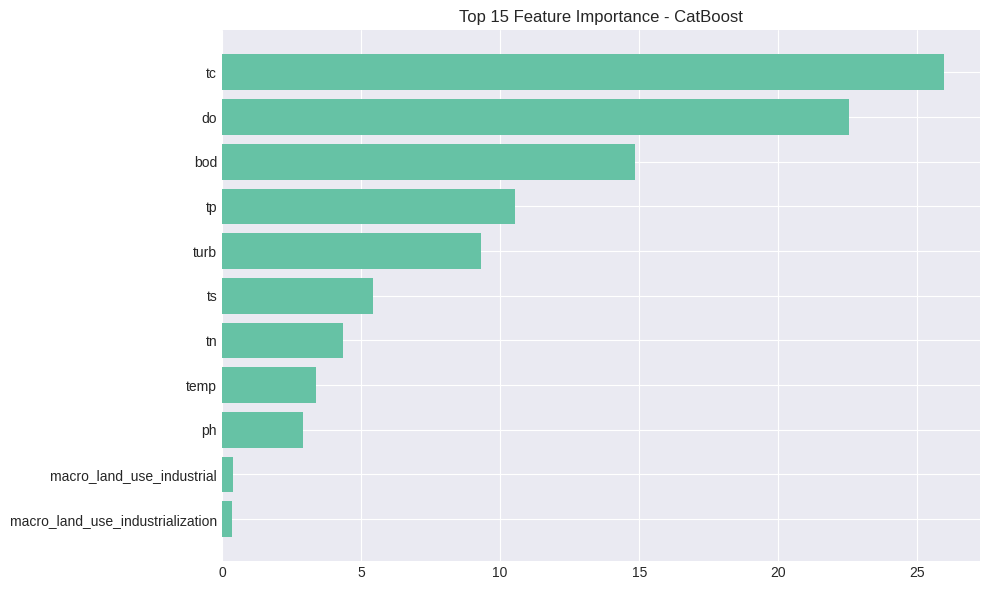


PROGRAM SELESAI. MENGGUNAKAN ADASYN + GRID SEARCH (parameter efisien).


In [ ]:


# ==============================================
# 9. PERBANDINGAN KETIGA ALGORITMA
# ==============================================
print("\n" + "="*60)
print("9. PERBANDINGAN MODEL")
print("="*60)

comparison = pd.DataFrame(results).T
print("\nTabel Perbandingan Metrik:")
print(comparison.round(4))

# Visualisasi perbandingan metrik utama
metrics = ['Accuracy', 'F1-Macro', 'F1-Weighted']
fig, ax = plt.subplots(figsize=(10,6))
comparison[metrics].plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Perbandingan Kinerja Antar Model (ADASYN + GridSearch)')
ax.set_ylabel('Skor')
ax.set_ylim(0.7, 1.0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)
plt.tight_layout()
plt.show()

# Model terbaik berdasarkan Accuracy
best_model_name = comparison['Accuracy'].idxmax()
best_accuracy = comparison.loc[best_model_name, 'Accuracy']
best_f1_macro = comparison.loc[best_model_name, 'F1-Macro']
print(f"\n{'='*60}")
print(f"MODEL TERBAIK BERDASARKAN AKURASI: {best_model_name}")
print(f"Akurasi: {best_accuracy:.4f}, F1-Macro: {best_f1_macro:.4f}")
print(f"{'='*60}")

# Feature importance untuk model terbaik
best_clf = best_models[best_model_name]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
feature_names = available_numeric + list(cat_feature_names)

if best_model_name == 'LightGBM' and hasattr(best_clf, 'feature_importances_'):
    importances = best_clf.feature_importances_
    indices = np.argsort(importances)[::-1][:15]
    plt.figure(figsize=(10,6))
    plt.title(f'Top 15 Feature Importance - {best_model_name}')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
elif best_model_name == 'CatBoost' and hasattr(best_clf, 'get_feature_importance'):
    importances = best_clf.get_feature_importance()
    indices = np.argsort(importances)[::-1][:15]
    plt.figure(figsize=(10,6))
    plt.title(f'Top 15 Feature Importance - {best_model_name}')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
elif best_model_name == 'HistGradientBoosting' and hasattr(best_clf, 'feature_importances_'):
    importances = best_clf.feature_importances_
    indices = np.argsort(importances)[::-1][:15]
    plt.figure(figsize=(10,6))
    plt.title(f'Top 15 Feature Importance - {best_model_name}')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("PROGRAM SELESAI. MENGGUNAKAN ADASYN + GRID SEARCH (parameter efisien).")
print("="*60)

In [ ]:
# ==============================================
# 10. MENYIMPAN MODEL DAN ARTEFAK UNTUK DEPLOYMENT
# ==============================================
print("\n" + "="*60)
print("10. MENYIMPAN MODEL DAN ARTEFAK UNTUK DEPLOYMENT")
print("="*60)

import pickle
import json
import os

# Buat folder deployment
deploy_folder = 'deployment_files'
os.makedirs(deploy_folder, exist_ok=True)

# 1. Simpan semua model (LightGBM, CatBoost, HistGradientBoosting)
for name, model in best_models.items():
    filename = name.lower().replace(' ', '_') + '.pkl'
    with open(os.path.join(deploy_folder, filename), 'wb') as f:
        pickle.dump(model, f)
    print(f"Model {name} disimpan ke {filename}")

# 2. Simpan preprocessor
with open(os.path.join(deploy_folder, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler disimpan ke scaler.pkl")

with open(os.path.join(deploy_folder, 'ohe.pkl'), 'wb') as f:
    pickle.dump(ohe, f)
print("OneHotEncoder disimpan ke ohe.pkl")

with open(os.path.join(deploy_folder, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)
print("LabelEncoder disimpan ke label_encoder.pkl")

# 3. Simpan informasi fitur
feature_info = {
    'numeric_cols': available_numeric,
    'categorical_cols': categorical_cols,
    'target_classes': le.classes_.tolist(),
    'best_model_name': best_model_name,
    'best_accuracy': float(best_accuracy),
    'models_available': list(best_models.keys())
}
with open(os.path.join(deploy_folder, 'feature_info.json'), 'w') as f:
    json.dump(feature_info, f, indent=2)
print("Informasi fitur disimpan ke feature_info.json")

print(f"\nSemua artefak telah disimpan di folder '{deploy_folder}'")
print("File yang dihasilkan:")
for f in os.listdir(deploy_folder):
    print(f"  - {f}")

print("\n" + "="*60)


10. MENYIMPAN MODEL DAN ARTEFAK UNTUK DEPLOYMENT
Model LightGBM disimpan ke lightgbm.pkl
Model CatBoost disimpan ke catboost.pkl
Model HistGradientBoosting disimpan ke histgradientboosting.pkl
Scaler disimpan ke scaler.pkl
OneHotEncoder disimpan ke ohe.pkl
LabelEncoder disimpan ke label_encoder.pkl
Informasi fitur disimpan ke feature_info.json

Semua artefak telah disimpan di folder 'deployment_files'
File yang dihasilkan:
  - scaler.pkl
  - lightgbm.pkl
  - feature_info.json
  - histgradientboosting.pkl
  - label_encoder.pkl
  - catboost.pkl
  - ohe.pkl

